<a href="https://www.kaggle.com/code/lalit7881/amazon-product-sales-data-42k-items-2025-eda-96?scriptVersionId=338465886" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/srisyra02/amazon-product-sales-data-42k-items-2025/amazon_sales_data_uncleaned.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/srisyra02/amazon-product-sales-data-42k-items-2025/amazon_sales_data_uncleaned.csv")

In [3]:
df.head()

,Title,Rating,Number_of_reviews,bought_in_last_month,Current/discounted_price,Price_on_variant,Listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,sustainability_badges,image_url,product_url,collected_at
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6 out of 5 stars,375,300+ bought in past month,89.68,basic variant price: 2.4GHz,$159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,"Delivery Mon, Sep 1",Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,21-08-2025 11:14
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3 out of 5 stars,"2,457",6K+ bought in past month,9.99,basic variant price: nan,$15.99,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Fri, Aug 29",NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,21-08-2025 11:14
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6 out of 5 stars,"3,044",2K+ bought in past month,314,basic variant price: nan,$349.00,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Mon, Sep 1",NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,21-08-2025 11:14
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6 out of 5 stars,"35,882",10K+ bought in past month,NaN,basic variant price: $162.24,No Discount,Best Seller,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61SUj2aKoE...,/Apple-Cancellation-Transparency-Personalized-...,21-08-2025 11:14
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8 out of 5 stars,"28,988",10K+ bought in past month,NaN,basic variant price: $72.74,No Discount,No Badge,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61bMNCeAUA...,/Apple-MX542LL-A-AirTag-Pack/dp/B0D54JZTHY/ref...,21-08-2025 11:14


In [4]:
df.tail()

,Title,Rating,Number_of_reviews,bought_in_last_month,Current/discounted_price,Price_on_variant,Listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,sustainability_badges,image_url,product_url,collected_at
42670,"Elgato 4K Pro, Internal Capture Card: 8K60 Pas...",5.0 out of 5 stars,1,100+ bought in past month,195.99,basic variant price: nan,No Discount,No Badge,Organic,No Coupon,NaN,"FREE delivery Thu, Sep 4Or fastest delivery Tu...",NaN,https://m.media-amazon.com/images/I/51KCB+egEs...,/Elgato-4K-Pro-Internal-Capture/dp/B0DLR3WQWR/...,30-08-2025 19:56
42671,"Arlo Essential Spotlight Camera, Wireless Secu...",4.2 out of 5 stars,20,200+ bought in past month,89.99,basic variant price: $25.00 off coupon applied,No Discount,No Badge,Organic,Save $25.00 with coupon,Add to cart,"FREE delivery Thu, Sep 4Or fastest delivery Mo...",NaN,https://m.media-amazon.com/images/I/51jV+o1LZE...,/Arlo-Essential-Spotlight-Camera-Surveillance/...,30-08-2025 19:56
42672,"GIGABYTE - AORUS FO32U2-32"" QD OLED Gaming Mon...",4.3 out of 5 stars,57,50+ bought in past month,899.99,basic variant price: Lowest price in 30 days,"$1,099.99",Save 18%,Organic,No Coupon,Add to cart,"FREE delivery Thu, Sep 4Or fastest delivery We...",NaN,https://m.media-amazon.com/images/I/71ySPkNLkG...,/GIGABYTE-FO32U2-32-3840x2160-240Hz-FreeSync-A...,30-08-2025 19:56
42673,Monoprice XLR Male to 1/4-Inch TRS Male Cable ...,4.7 out of 5 stars,"7,102",500+ bought in past month,10.39,basic variant price: nan,$15.98,No Badge,Organic,No Coupon,Add to cart,"FREE delivery Thu, Sep 4 on $35 of items shipp...",NaN,https://m.media-amazon.com/images/I/411c0JFJ79...,/Monoprice-XLR-Male-4-Inch-Cable/dp/B001UJEKZ6...,30-08-2025 19:56
42674,Lorex Fusion 1080p HD Security Camera System w...,4.4 out of 5 stars,75,50+ bought in past month,419.99,basic variant price: nan,$499.99,No Badge,Organic,No Coupon,Add to cart,"FREE delivery Thu, Sep 4Or fastest delivery We...",NaN,https://m.media-amazon.com/images/I/71wTn+zoSr...,/Lorex-8-Channel-Security-Outdoor-Cameras/dp/B...,30-08-2025 19:56


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42675 entries, 0 to 42674
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Title                     42675 non-null  object
 1   Rating                    41651 non-null  object
 2   Number_of_reviews         41651 non-null  object
 3   bought_in_last_month      39458 non-null  object
 4   Current/discounted_price  30926 non-null  object
 5   Price_on_variant          42675 non-null  object
 6   Listed_price              42675 non-null  object
 7   is_best_seller            42675 non-null  object
 8   is_sponsored              42675 non-null  object
 9   is_couponed               42675 non-null  object
 10  buy_box_availability      28022 non-null  object
 11  delivery_details          30955 non-null  object
 12  sustainability_badges     3408 non-null   object
 13  image_url                 42675 non-null  object
 14  product_url           

In [6]:
df.isnull().sum()

Title                           0
Rating                       1024
Number_of_reviews            1024
bought_in_last_month         3217
Current/discounted_price    11749
Price_on_variant                0
Listed_price                    0
is_best_seller                  0
is_sponsored                    0
is_couponed                     0
buy_box_availability        14653
delivery_details            11720
sustainability_badges       39267
image_url                       0
product_url                  2069
collected_at                    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(962)

In [8]:
df.dtypes

Title                       object
Rating                      object
Number_of_reviews           object
bought_in_last_month        object
Current/discounted_price    object
Price_on_variant            object
Listed_price                object
is_best_seller              object
is_sponsored                object
is_couponed                 object
buy_box_availability        object
delivery_details            object
sustainability_badges       object
image_url                   object
product_url                 object
collected_at                object
dtype: object

In [9]:
df.shape

(42675, 16)

In [10]:
df.columns

Index(['Title', 'Rating', 'Number_of_reviews', 'bought_in_last_month',
       'Current/discounted_price', 'Price_on_variant', 'Listed_price',
       'is_best_seller', 'is_sponsored', 'is_couponed', 'buy_box_availability',
       'delivery_details', 'sustainability_badges', 'image_url', 'product_url',
       'collected_at'],
      dtype='object')

In [11]:
df.nunique()

Title                        8808
Rating                         31
Number_of_reviews            4413
bought_in_last_month           59
Current/discounted_price     2576
Price_on_variant             3466
Listed_price                  911
is_best_seller                 12
is_sponsored                    2
is_couponed                    42
buy_box_availability            1
delivery_details              298
sustainability_badges          16
image_url                    8038
product_url                 40606
collected_at                  331
dtype: int64

## EDA

In [12]:
# Convert Rating to numeric
df["Rating"] = (
    df["Rating"]
    .astype(str)
    .str.extract(r'(\d+\.?\d*)')[0]
)

df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

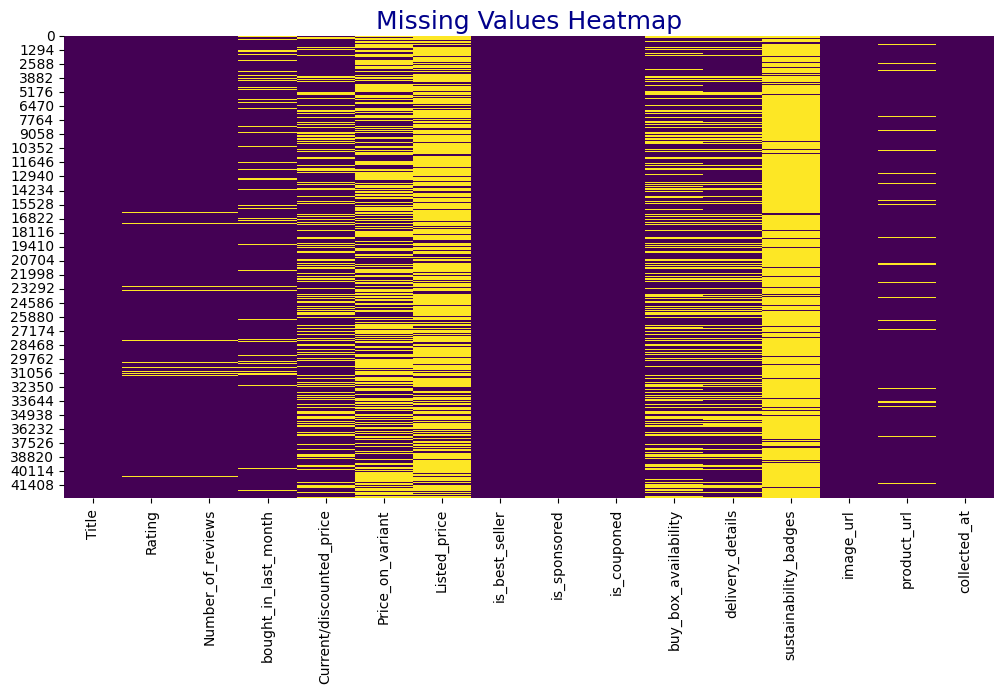

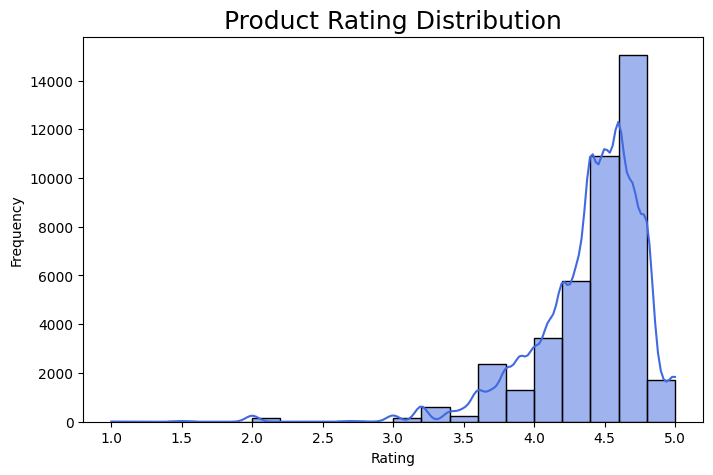

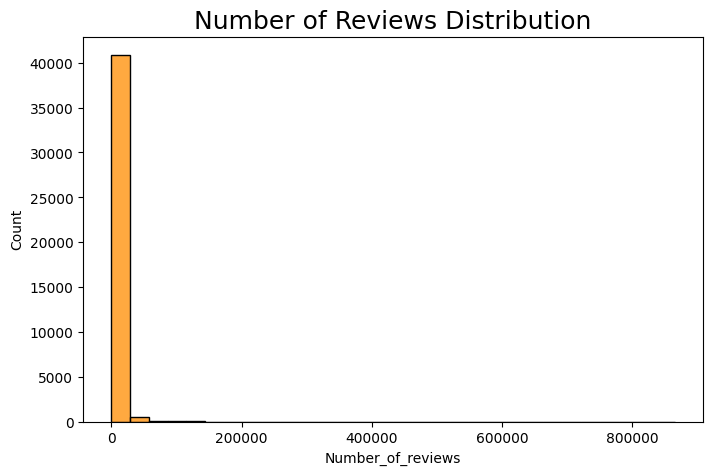

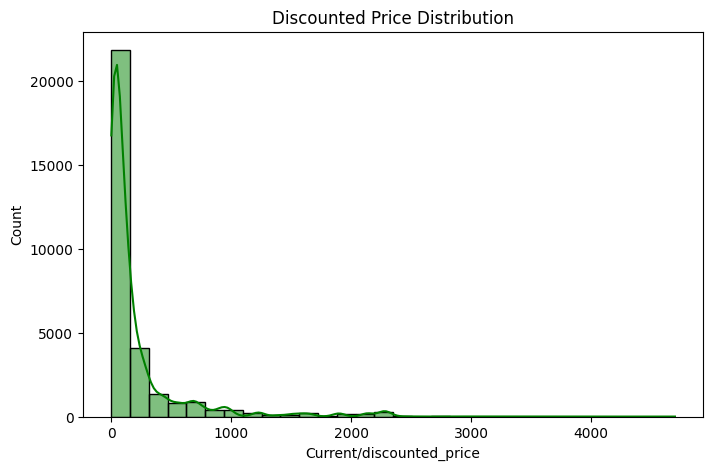

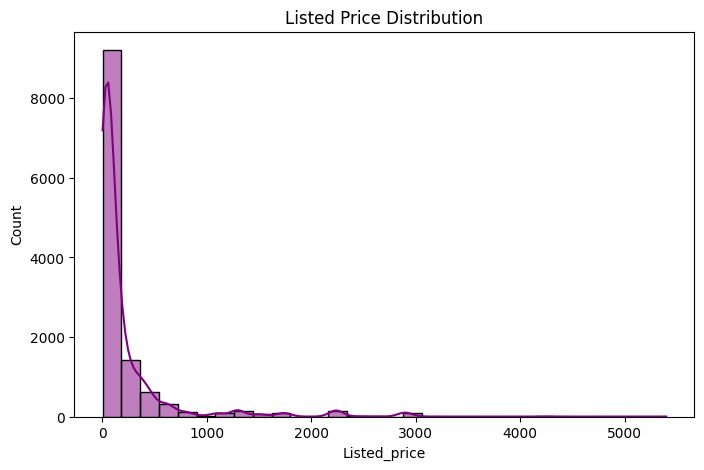

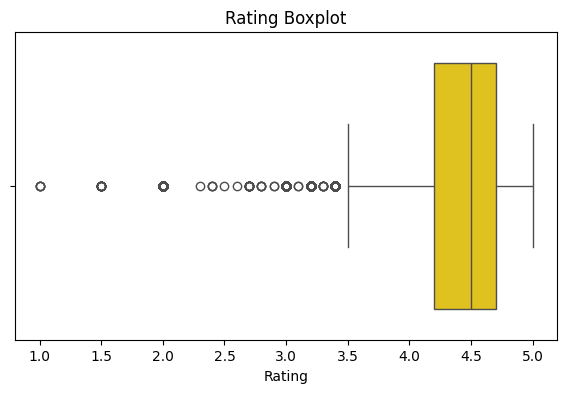

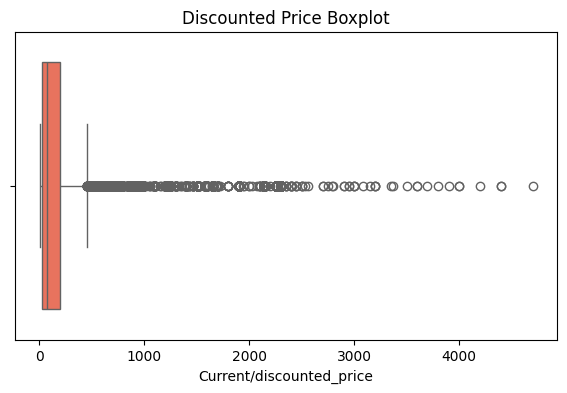

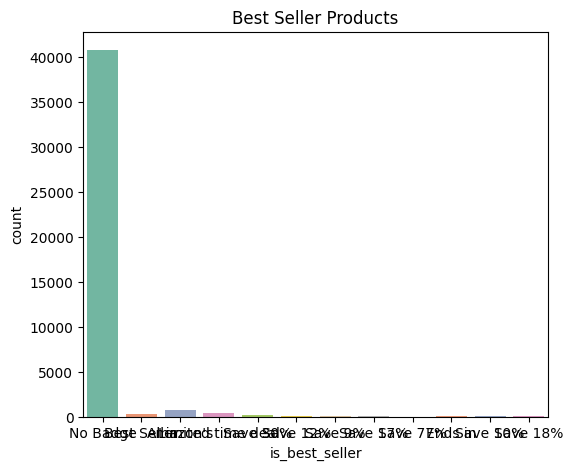

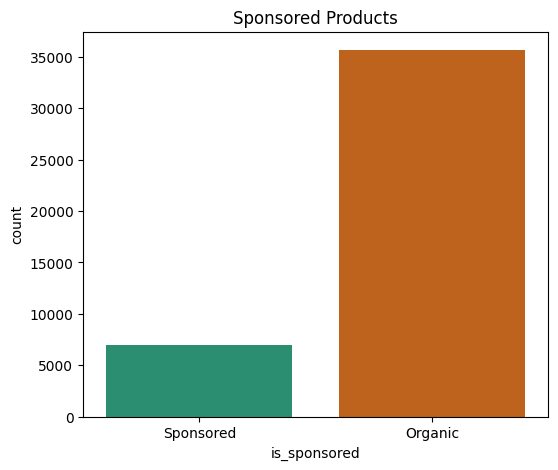

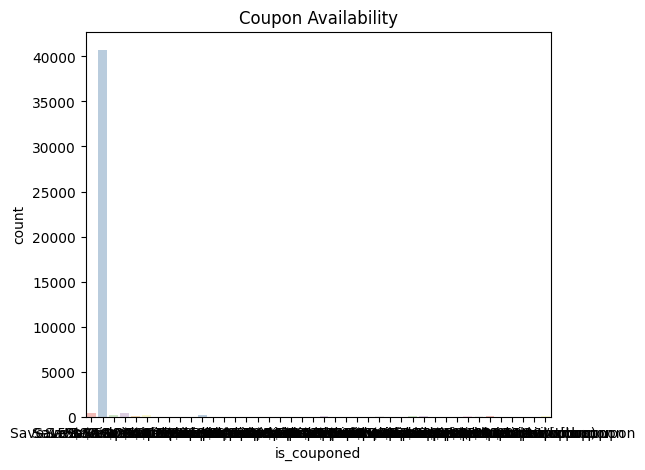

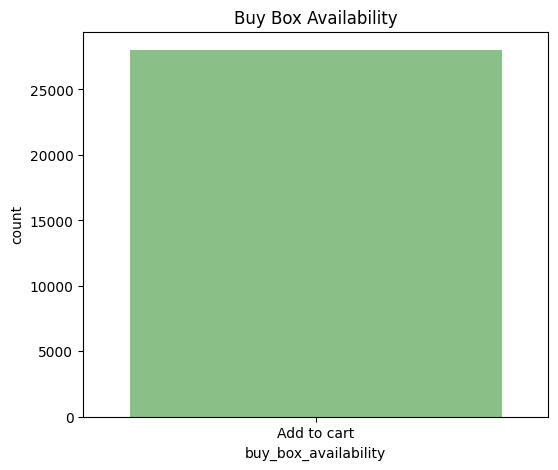

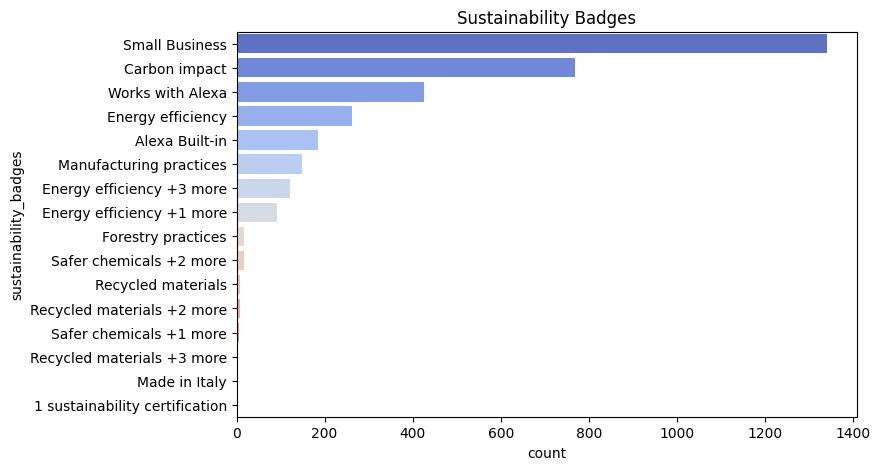

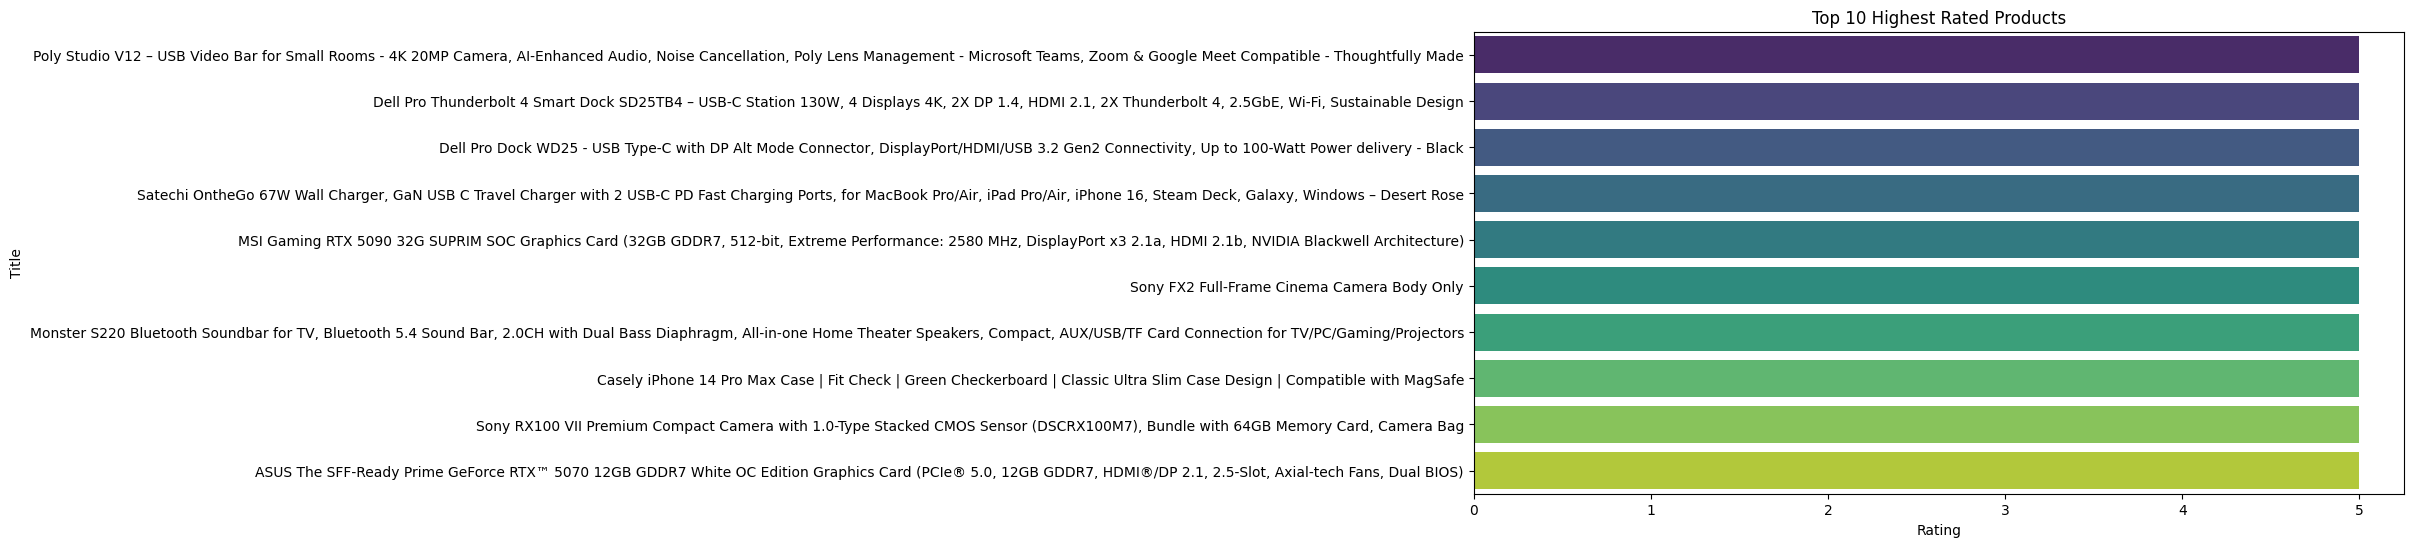

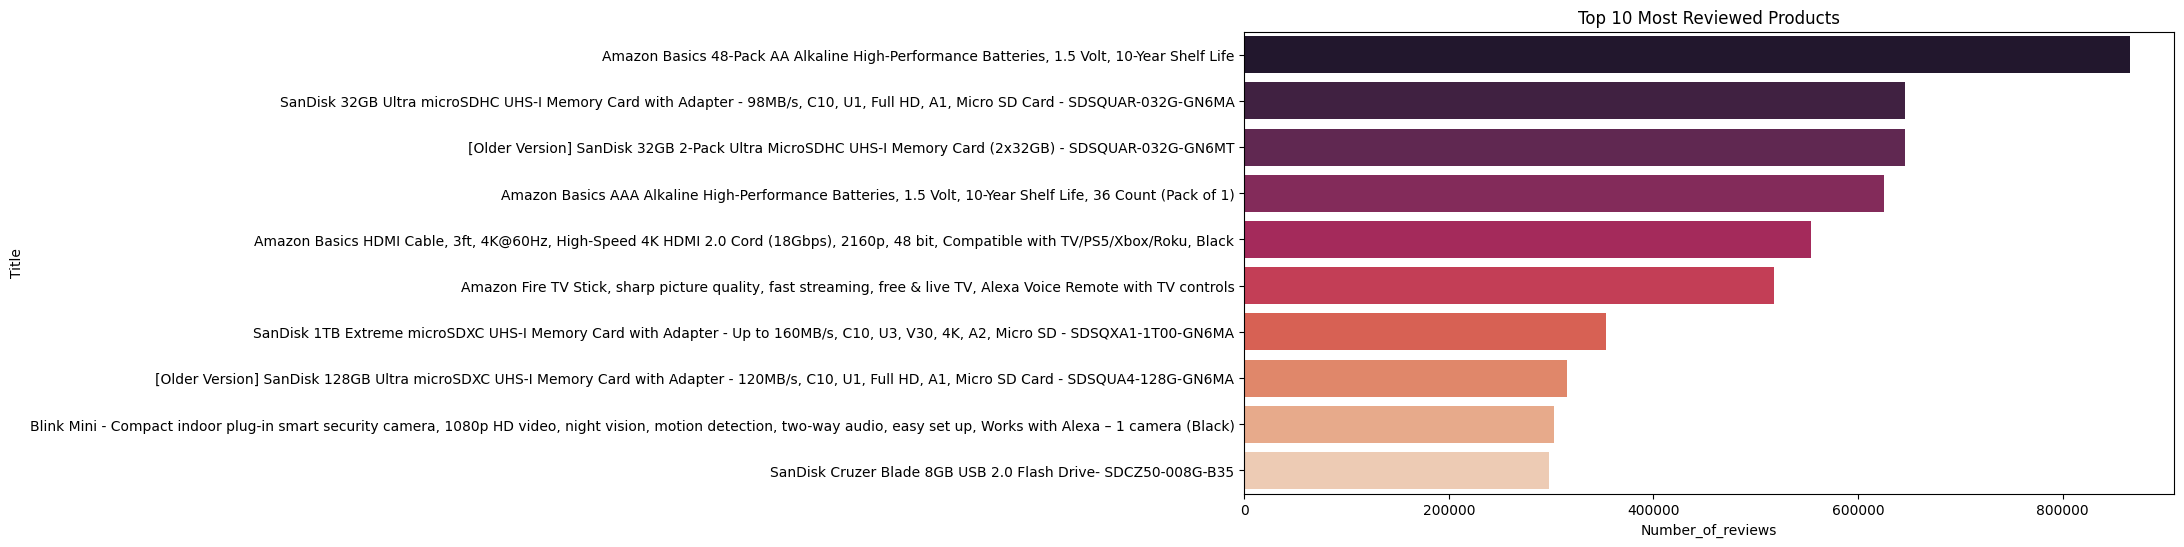

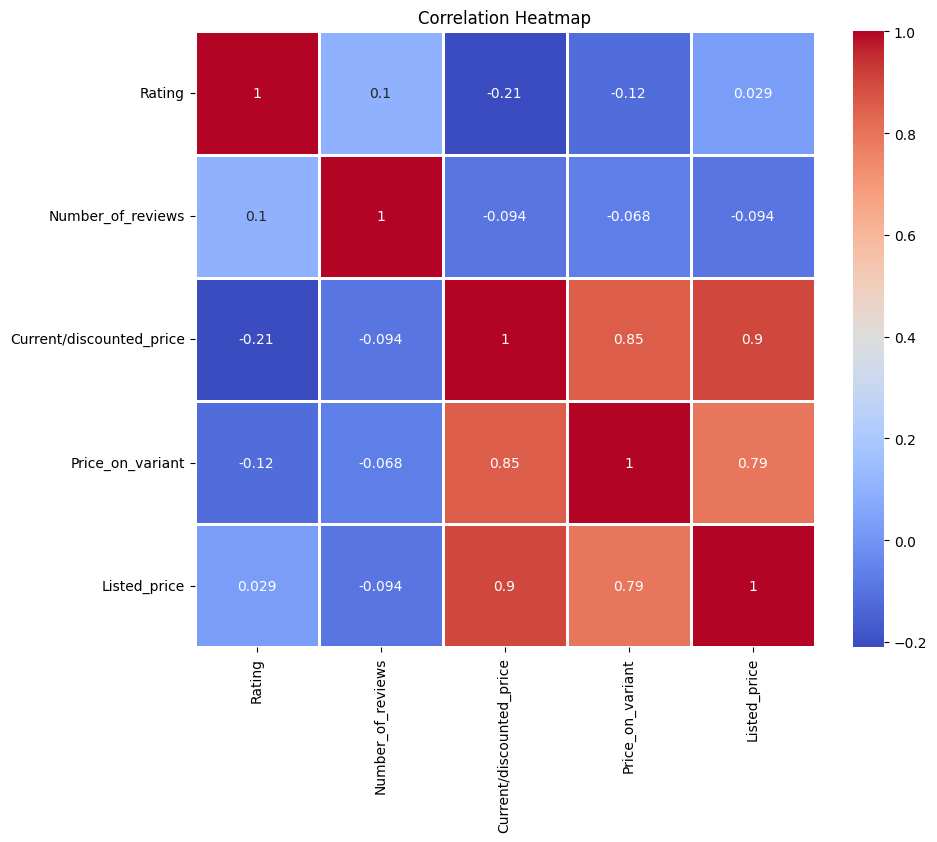

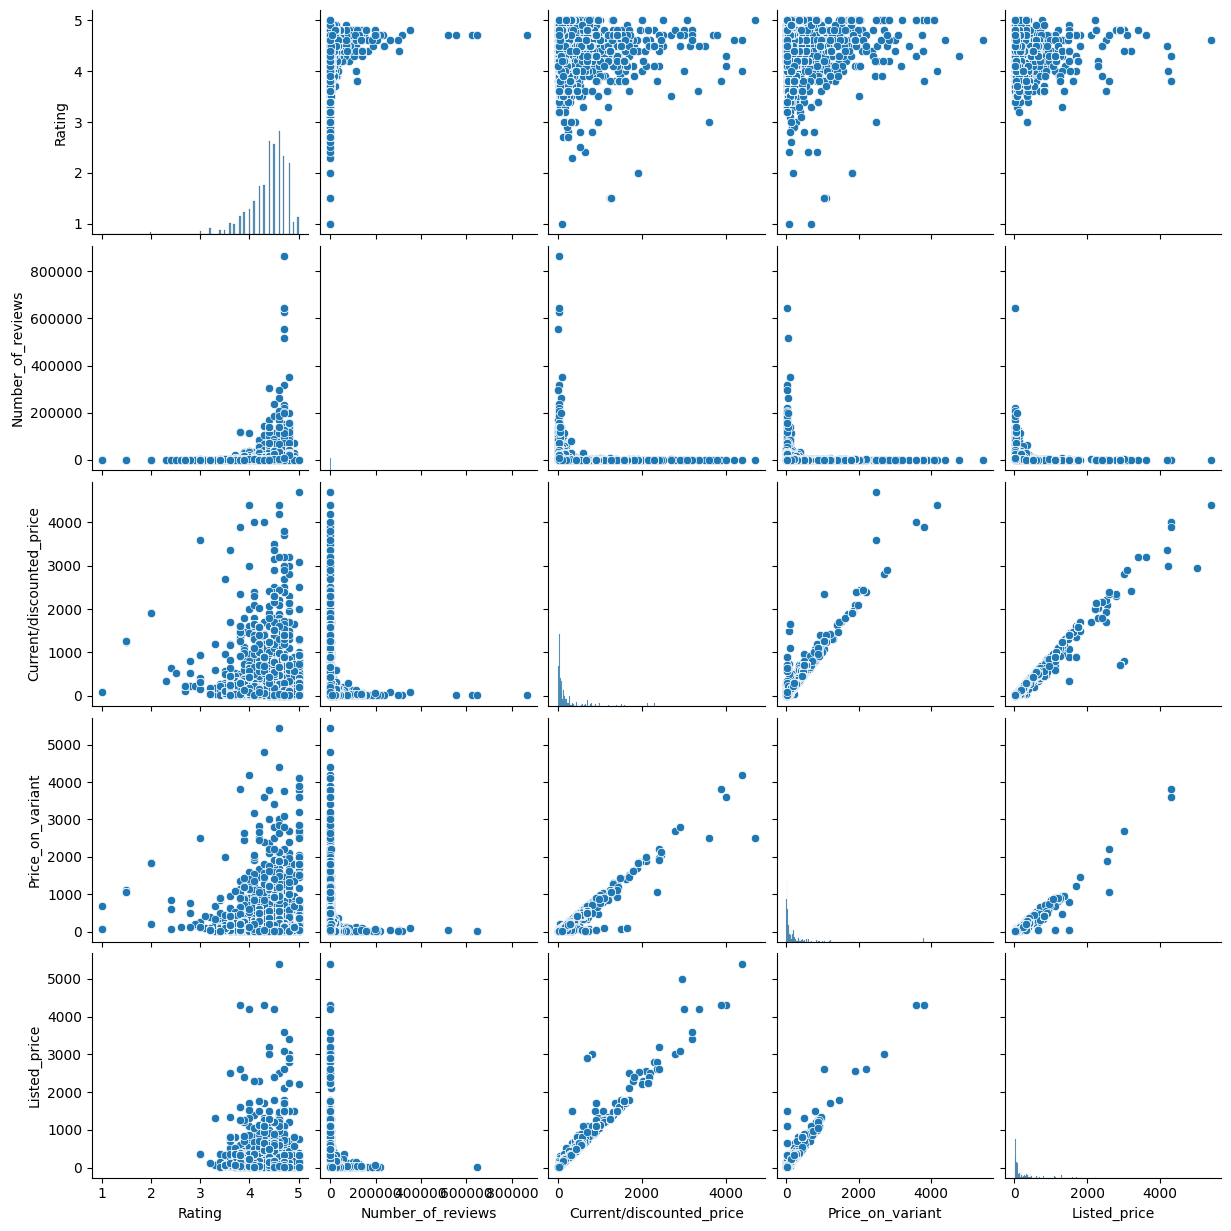

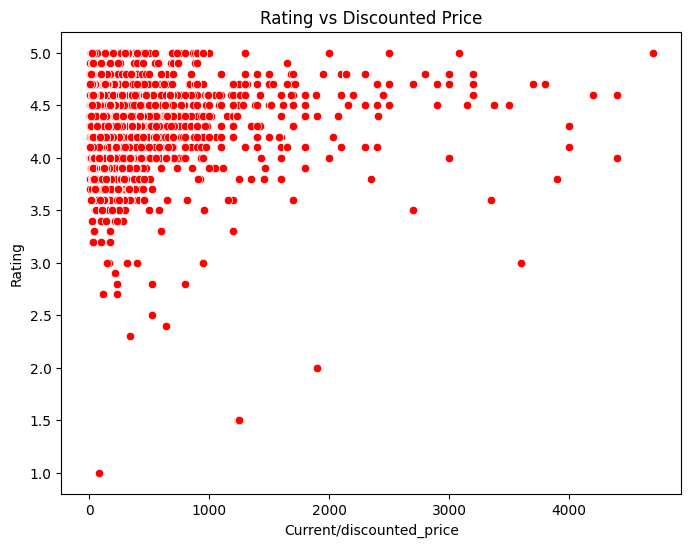

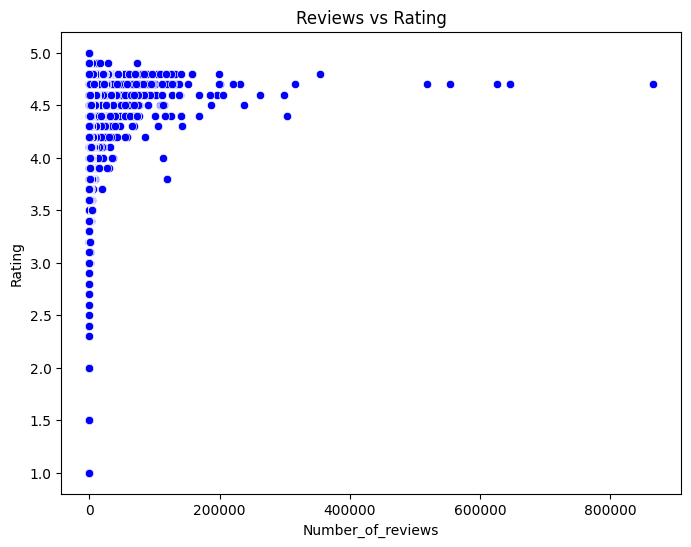

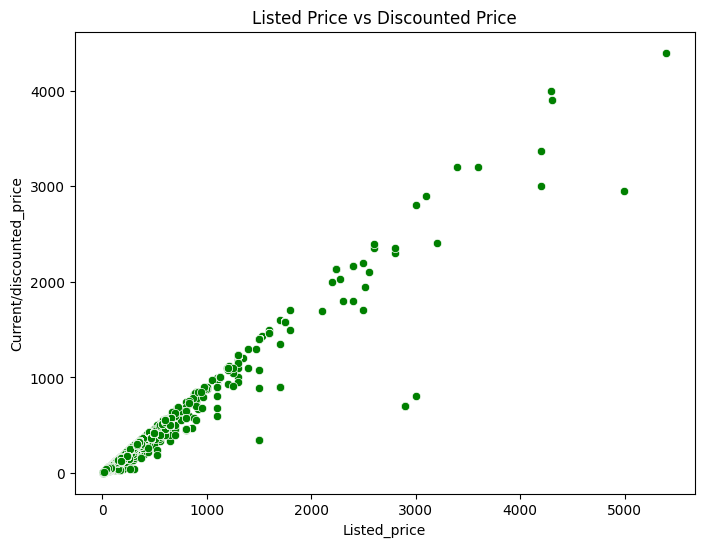

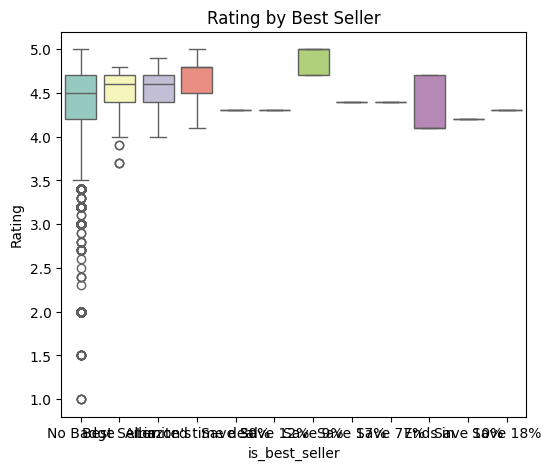

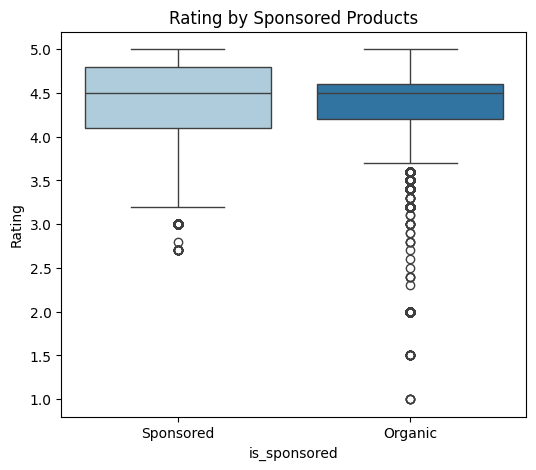

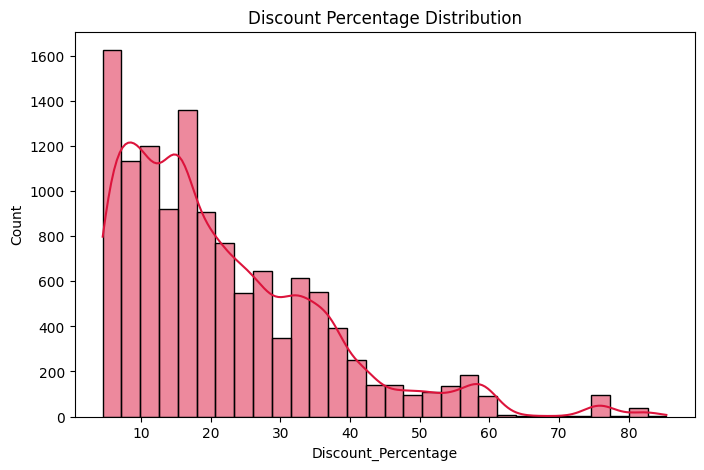

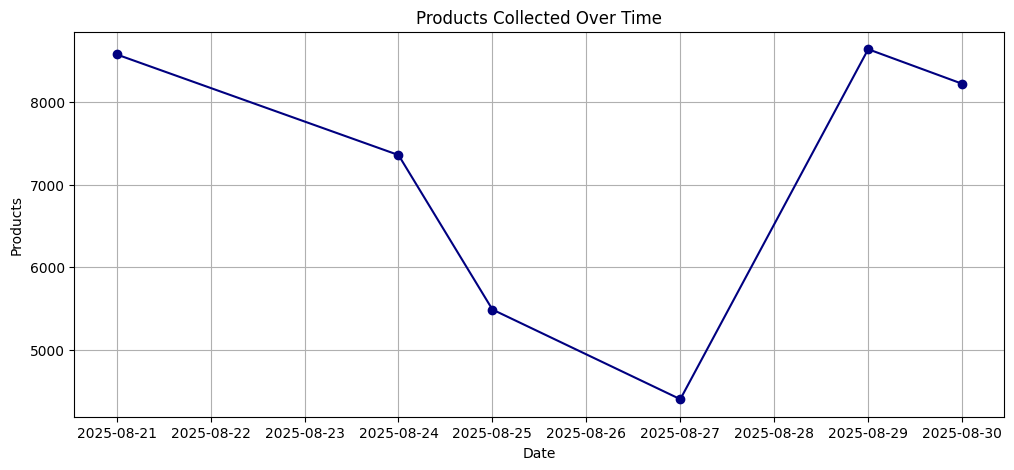

All EDA Visualizations Completed Successfully.


In [13]:
price_cols = [
    "Current/discounted_price",
    "Price_on_variant",
    "Listed_price"
]

for col in price_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace("₹","",regex=False)
        .str.replace(",","",regex=False)
        .str.extract("(\d+\.?\d*)")[0]
        .astype(float)
    )

# ============================================================
# Convert Reviews into Numeric
# ============================================================

df["Number_of_reviews"] = (
    df["Number_of_reviews"]
    .astype(str)
    .str.replace(",","")
)

df["Number_of_reviews"] = pd.to_numeric(
    df["Number_of_reviews"],
    errors="coerce"
)

# ============================================================
# Missing Values Heatmap
# ============================================================

plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(),
            cmap="viridis",
            cbar=False)

plt.title("Missing Values Heatmap",
          fontsize=18,
          color="darkblue")
plt.show()

# ============================================================
# Rating Distribution
# ============================================================

plt.figure(figsize=(8,5))
sns.histplot(df["Rating"],
             bins=20,
             kde=True,
             color="royalblue")

plt.title("Product Rating Distribution",
          fontsize=18)
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

# ============================================================
# Reviews Distribution
# ============================================================

plt.figure(figsize=(8,5))
sns.histplot(df["Number_of_reviews"],
             bins=30,
             color="darkorange")

plt.title("Number of Reviews Distribution",
          fontsize=18)
plt.show()

# ============================================================
# Discounted Price Distribution
# ============================================================

plt.figure(figsize=(8,5))
sns.histplot(df["Current/discounted_price"],
             bins=30,
             kde=True,
             color="green")

plt.title("Discounted Price Distribution")
plt.show()

# ============================================================
# Listed Price Distribution
# ============================================================

plt.figure(figsize=(8,5))
sns.histplot(df["Listed_price"],
             bins=30,
             kde=True,
             color="purple")

plt.title("Listed Price Distribution")
plt.show()

# ============================================================
# Rating Boxplot
# ============================================================

plt.figure(figsize=(7,4))
sns.boxplot(x=df["Rating"],
            color="gold")

plt.title("Rating Boxplot")
plt.show()

# ============================================================
# Discounted Price Boxplot
# ============================================================

plt.figure(figsize=(7,4))
sns.boxplot(x=df["Current/discounted_price"],
            color="tomato")

plt.title("Discounted Price Boxplot")
plt.show()

# ============================================================
# Best Seller Count
# ============================================================

plt.figure(figsize=(6,5))
sns.countplot(
    x="is_best_seller",
    data=df,
    palette="Set2"
)

plt.title("Best Seller Products")
plt.show()

# ============================================================
# Sponsored Products Count
# ============================================================

plt.figure(figsize=(6,5))
sns.countplot(
    x="is_sponsored",
    data=df,
    palette="Dark2"
)

plt.title("Sponsored Products")
plt.show()

# ============================================================
# Coupon Availability
# ============================================================

plt.figure(figsize=(6,5))
sns.countplot(
    x="is_couponed",
    data=df,
    palette="Pastel1"
)

plt.title("Coupon Availability")
plt.show()

# ============================================================
# Buy Box Availability
# ============================================================

plt.figure(figsize=(6,5))
sns.countplot(
    x="buy_box_availability",
    data=df,
    palette="Accent"
)

plt.title("Buy Box Availability")
plt.show()

# ============================================================
# Sustainability Badges
# ============================================================

plt.figure(figsize=(8,5))
sns.countplot(
    y="sustainability_badges",
    data=df,
    palette="coolwarm",
    order=df["sustainability_badges"].value_counts().index
)

plt.title("Sustainability Badges")
plt.show()

# ============================================================
# Top 10 Highest Rated Products
# ============================================================

top_rating = df.nlargest(10,"Rating")

plt.figure(figsize=(12,6))
sns.barplot(
    x="Rating",
    y="Title",
    data=top_rating,
    palette="viridis"
)

plt.title("Top 10 Highest Rated Products")
plt.show()

# ============================================================
# Top 10 Most Reviewed Products
# ============================================================

top_reviews = df.nlargest(10,"Number_of_reviews")

plt.figure(figsize=(12,6))
sns.barplot(
    x="Number_of_reviews",
    y="Title",
    data=top_reviews,
    palette="rocket"
)

plt.title("Top 10 Most Reviewed Products")
plt.show()

# ============================================================
# Correlation Heatmap
# ============================================================

numeric = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))
sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=1
)

plt.title("Correlation Heatmap")
plt.show()

# ============================================================
# Pairplot
# ============================================================

sns.pairplot(
    numeric,
    palette="husl"
)

plt.show()

# ============================================================
# Rating vs Discounted Price
# ============================================================

plt.figure(figsize=(8,6))
sns.scatterplot(
    x="Current/discounted_price",
    y="Rating",
    data=df,
    color="red"
)

plt.title("Rating vs Discounted Price")
plt.show()

# ============================================================
# Reviews vs Rating
# ============================================================

plt.figure(figsize=(8,6))
sns.scatterplot(
    x="Number_of_reviews",
    y="Rating",
    data=df,
    color="blue"
)

plt.title("Reviews vs Rating")
plt.show()

# ============================================================
# Listed Price vs Discounted Price
# ============================================================

plt.figure(figsize=(8,6))
sns.scatterplot(
    x="Listed_price",
    y="Current/discounted_price",
    data=df,
    color="green"
)

plt.title("Listed Price vs Discounted Price")
plt.show()

# ============================================================
# Rating by Best Seller
# ============================================================

plt.figure(figsize=(6,5))
sns.boxplot(
    x="is_best_seller",
    y="Rating",
    data=df,
    palette="Set3"
)

plt.title("Rating by Best Seller")
plt.show()

# ============================================================
# Rating by Sponsored Products
# ============================================================

plt.figure(figsize=(6,5))
sns.boxplot(
    x="is_sponsored",
    y="Rating",
    data=df,
    palette="Paired"
)

plt.title("Rating by Sponsored Products")
plt.show()

# ============================================================
# Discount Percentage
# ============================================================

df["Discount_Percentage"] = (
    (df["Listed_price"] -
     df["Current/discounted_price"])
    / df["Listed_price"] * 100
)

plt.figure(figsize=(8,5))
sns.histplot(
    df["Discount_Percentage"],
    bins=30,
    kde=True,
    color="crimson"
)

plt.title("Discount Percentage Distribution")
plt.show()

# ============================================================
# Collection Time Trend
# ============================================================

df["collected_at"] = pd.to_datetime(
    df["collected_at"],
    errors="coerce"
)

collection = df.groupby(
    df["collected_at"].dt.date
).size()

plt.figure(figsize=(12,5))
collection.plot(
    color="navy",
    marker="o"
)

plt.title("Products Collected Over Time")
plt.xlabel("Date")
plt.ylabel("Products")
plt.grid(True)
plt.show()

# ============================================================
# End of Visualization
# ============================================================

print("All EDA Visualizations Completed Successfully.")

## Feature engineering

In [14]:
import numpy as np

# Numeric columns
num_cols = df.select_dtypes(include=np.number).columns

# Categorical columns
cat_cols = df.select_dtypes(include=["object", "category"]).columns

# Fill numeric missing values
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after filling:")
print(df.isnull().sum().sum())

Missing values after filling:
0


Logistic Regression
Accuracy : 95.52%
Precision: 91.47%
Recall   : 95.52%
F1 Score : 93.45%

Confusion Matrix
[[   0    0    0    0  149    0    0    0    0    0    0]
 [   0    0    0    0   55    0    0    0    0    0    0]
 [   0    0    0    0   19    0    0    0    0    0    0]
 [   0    0    0    0   82    0    0    0    0    0    0]
 [   0    1    0    0 8153    6    2    0    1    0    0]
 [   0    0    0    0   12    0    0    0    0    0    0]
 [   0    0    0    0    5    0    0    0    0    0    0]
 [   0    0    0    0   10    0    0    0    0    0    0]
 [   0    0    0    0   12    0    0    0    0    0    0]
 [   0    0    0    0   25    0    0    0    0    0    0]
 [   0    0    0    0    3    0    0    0    0    0    0]]
Decision Tree
Accuracy : 96.32%
Precision: 95.34%
Recall   : 96.32%
F1 Score : 95.75%

Confusion Matrix
[[   4    2    0    1  137    0    3    0    1    1    0]
 [   4   19    0    0   32    0    0    0    0    0    0]
 [   0    0   19    0    0    0

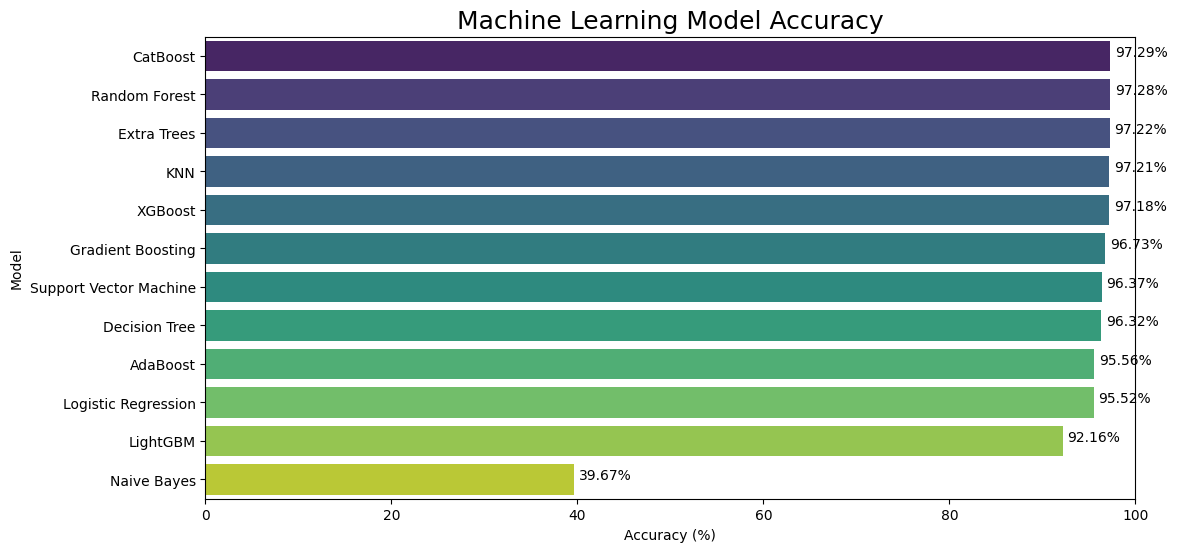


Best Model
Model             CatBoost
Accuracy (%)     97.293497
Precision (%)    95.546917
Recall (%)       97.293497
F1 Score (%)     96.262956
Name: 11, dtype: object


In [15]:
# ============================================================
# Drop Unnecessary Columns
# ============================================================

drop_cols = [
    "Title",
    "image_url",
    "product_url",
    "delivery_details",
    "collected_at"
]

drop_cols = [c for c in drop_cols if c in df.columns]

df.drop(columns=drop_cols, inplace=True)

# ============================================================
# Convert Price Columns
# ============================================================

price_cols = [
    "Current/discounted_price",
    "Price_on_variant",
    "Listed_price"
]

for col in price_cols:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace("₹","",regex=False)
            .str.replace(",","",regex=False)
            .str.extract(r'(\d+\.?\d*)')[0]
        )
        df[col] = pd.to_numeric(df[col], errors="coerce")

# ============================================================
# Rating
# ============================================================

if "Rating" in df.columns:
    df["Rating"] = (
        df["Rating"]
        .astype(str)
        .str.extract(r'(\d+\.?\d*)')[0]
    )
    df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

# ============================================================
# Number of Reviews
# ============================================================

if "Number_of_reviews" in df.columns:

    df["Number_of_reviews"] = (
        df["Number_of_reviews"]
        .astype(str)
        .str.replace(",","",regex=False)
        .str.extract(r'(\d+\.?\d*)')[0]
    )

    df["Number_of_reviews"] = pd.to_numeric(
        df["Number_of_reviews"],
        errors="coerce"
    )

# ============================================================
# Replace Infinite Values
# ============================================================

df.replace([np.inf,-np.inf],np.nan,inplace=True)

# ============================================================
# Fill Missing Values
# ============================================================

num_cols = df.select_dtypes(include=np.number).columns

cat_cols = df.select_dtypes(include="object").columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# ============================================================
# Label Encoding
# ============================================================

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in cat_cols:
    df[col] = encoder.fit_transform(df[col].astype(str))

# ============================================================
# Target Column
# ============================================================

target = "is_best_seller"

X = df.drop(target, axis=1)

y = df[target]

# ============================================================
# Encode Target
# ============================================================

if y.dtype == "object":
    y = LabelEncoder().fit_transform(y)

# ============================================================
# Train Test Split
# ============================================================

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ============================================================
# Feature Scaling
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# ============================================================
# Machine Learning Models
# ============================================================

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from sklearn.neighbors import KNeighborsClassifier

from sklearn.naive_bayes import GaussianNB

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

models = {

    "Logistic Regression":
    LogisticRegression(max_iter=1000),

    "Decision Tree":
    DecisionTreeClassifier(random_state=42),

    "Random Forest":
    RandomForestClassifier(random_state=42),

    "Extra Trees":
    ExtraTreesClassifier(random_state=42),

    "KNN":
    KNeighborsClassifier(),

    "Naive Bayes":
    GaussianNB(),

    "Support Vector Machine":
    SVC(),

    "AdaBoost":
    AdaBoostClassifier(random_state=42),

    "Gradient Boosting":
    GradientBoostingClassifier(random_state=42)

}

# ============================================================
# Optional Models
# ============================================================

try:
    from xgboost import XGBClassifier

    models["XGBoost"] = XGBClassifier(
        eval_metric="logloss",
        random_state=42
    )

except:
    print("XGBoost not installed.")

try:
    from lightgbm import LGBMClassifier

    models["LightGBM"] = LGBMClassifier(random_state=42)

except:
    print("LightGBM not installed.")

try:
    from catboost import CatBoostClassifier

    models["CatBoost"] = CatBoostClassifier(
        verbose=0,
        random_state=42
    )

except:
    print("CatBoost not installed.")

# ============================================================
# Train Models
# ============================================================

results=[]

for name,model in models.items():

    print("="*70)
    print(name)

    if name in [
        "Logistic Regression",
        "KNN",
        "Support Vector Machine"
    ]:

        model.fit(X_train_scaled,y_train)

        pred=model.predict(X_test_scaled)

    else:

        model.fit(X_train,y_train)

        pred=model.predict(X_test)

    acc=accuracy_score(y_test,pred)*100

    pre=precision_score(
        y_test,
        pred,
        average="weighted",
        zero_division=0
    )*100

    rec=recall_score(
        y_test,
        pred,
        average="weighted",
        zero_division=0
    )*100

    f1=f1_score(
        y_test,
        pred,
        average="weighted",
        zero_division=0
    )*100

    print("Accuracy : {:.2f}%".format(acc))
    print("Precision: {:.2f}%".format(pre))
    print("Recall   : {:.2f}%".format(rec))
    print("F1 Score : {:.2f}%".format(f1))

    print("\nConfusion Matrix")

    print(confusion_matrix(y_test,pred))

    results.append([
        name,
        acc,
        pre,
        rec,
        f1
    ])

# ============================================================
# Accuracy Table
# ============================================================

result_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy (%)",
        "Precision (%)",
        "Recall (%)",
        "F1 Score (%)"
    ]
)

result_df = result_df.sort_values(
    by="Accuracy (%)",
    ascending=False
)

print("\n")
print("="*70)
print("MODEL PERFORMANCE")
print("="*70)

print(result_df)

# ============================================================
# Accuracy Graph
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    data=result_df,
    x="Accuracy (%)",
    y="Model",
    palette="viridis"
)

plt.title("Machine Learning Model Accuracy",fontsize=18)

plt.xlabel("Accuracy (%)")

plt.ylabel("Model")

plt.xlim(0,100)

for index,value in enumerate(result_df["Accuracy (%)"]):
    plt.text(value+0.5,index,f"{value:.2f}%")

plt.show()

# ============================================================
# Best Model
# ============================================================

print("\nBest Model")

print(result_df.iloc[0])

## Thank you..pls upvote!!!!!!!!!!